---
title: "Лабораторна робота №4. Латентно-семантичні моделі та тематичне моделювання тексту"
description: "Технології аналізу текстової інформації та машинне навчання | КрНУ ім. М. Остроградського"
author: "&copy; Роменський В'ячеслав"
date: today
format:
  html:
    toc: true
    toc-depth: 4
    toc-location: right
    code-fold: false
    code-tools: true
    embed-resources: true
    smooth-scroll: true
jupyter: python3
---



## Мета роботи

Опанувати базові підходи до *латентного представлення текстів*: побудову *TF-IDF*-матриці, застосування *LSA* на основі *SVD*, побудову *LDA*-моделі та інтерпретацію латентних тем у корпусі документів.


## Що Ви будете вміти після виконання роботи?

Після виконання лабораторної роботи Ви будеш вміти:

- формувати невеликий навчальний корпус для тематичного аналізу;
- виконувати базове очищення та токенізацію текстів;
- будувати матриці *документ–термін* у схемах *TF-IDF* та *Count*;
- застосовувати *LSA* як метод зниження розмірності та виявлення прихованих смислових напрямів;
- будувати *LDA* як ймовірнісну модель тем;
- візуалізувати документи у просторі латентних компонент і тем;
- інтерпретувати результати тематичного моделювання на основі топ-слів.


## Теоретичні відомості

У лекції 4 було показано, що класичні моделі *Bag of Words* і *TF-IDF* добре відображають частотну структуру корпусу, але не завжди дозволяють побачити його *приховану семантичну організацію*.

У цій роботі розглядаються два фундаментальні підходи:

1. *LSA (Latent Semantic Analysis)* -- лінійно-алгебраїчний підхід, який використовує *SVD* для переходу від високовимірної матриці термінів до компактного латентного простору.
2. *LDA (Latent Dirichlet Allocation)* -- ймовірнісна тематична модель, де кожен документ задається як суміш тем, а кожна тема -- як розподіл імовірностей за словами.

Таким чином, LSA більше відповідає на питання *«де розташований документ у латентному просторі?»*, а LDA -- на питання *«з яких тем складається документ?»*.


## Постановка завдання

Потрібно сформувати *навчальний корпус документів* і виконати для нього такі кроки:

1. підготувати корпус до тематичного аналізу;
2. виконати базове очищення текстів;
3. побудувати *TF-IDF*-матрицю;
4. застосувати *LSA* і дослідити латентний простір документів;
5. побудувати *biplot* для документів і термінів у просторі перших двох компонент;
6. побудувати *LDA*-модель;
7. інтерпретувати теми на основі топ-слів;
8. виконати графічний аналіз простору тем;
9. зробити змістовні висновки щодо відмінностей між *LSA* та *LDA*.


In [47]:
# Базові імпорти
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation


## 1. Формування базового корпусу

Нижче наведено невеликий навчальний корпус українською мовою.  
Документи спеціально підібрано так, щоб у корпусі були *кілька тематичних груп*:

- аналіз тексту та машинне навчання;
- соціальні медіа і моніторинг;
- спорт і тренування.

Це дозволить краще побачити, як латентні моделі виявляють приховані смислові структури.


In [15]:
base_corpus = [
    "машинне навчання допомагає знаходити закономірності в текстових даних і будувати моделі класифікації",
    "аналіз тексту включає токенізацію векторизацію tf idf та тематичне моделювання документів",
    "обробка природної мови використовує статистичні моделі та нейромережеві підходи",
    "моніторинг соціальних медіа передбачає збирання повідомлень аналіз сентименту та виявлення тем",
    "чатові дискусії у соціальних мережах можуть містити приховані інформаційні кампанії",
    "виявлення ботів і тролів спирається на аналіз текстового контенту та поведінкових ознак",
    "футбольна команда провела інтенсивне тренування і покращила швидкість передачі м'яча",
    "спортсмени аналізують тактику гри фізичну форму та результати попередніх матчів",
    "тренер оцінив якість захисту командну взаємодію та ефективність ударів по воротах"
]

base_df = pd.DataFrame({
    "doc_id": [f"D{i+1}" for i in range(len(base_corpus))],
    "text": base_corpus
})

csv_path = Path("data\\lab4_variant2_science_education.csv")

if csv_path.exists():
    loaded_df = pd.read_csv(csv_path)
    corpus_df = pd.concat([base_df, loaded_df], ignore_index=True)
else:
    print(f"Файл {csv_path} не знайдено.")

display(corpus_df)
print("Завантажено документів:", len(corpus_df))

,doc_id,text
0,D1,машинне навчання допомагає знаходити закономір...
1,D2,аналіз тексту включає токенізацію векторизацію...
2,D3,обробка природної мови використовує статистичн...
3,D4,моніторинг соціальних медіа передбачає збиранн...
4,D5,чатові дискусії у соціальних мережах можуть мі...
5,D6,виявлення ботів і тролів спирається на аналіз ...
6,D7,футбольна команда провела інтенсивне тренуванн...
7,D8,спортсмени аналізують тактику гри фізичну форм...
8,D9,тренер оцінив якість захисту командну взаємоді...
9,V2_1,наукові статті з машинного навчання описують м...


Завантажено документів: 17


## 2. Базове очищення тексту

Виконаємо очищення, токенізацію, фільтрацію, стемінг.


In [27]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = text.replace("’", "'").replace("`", "'")
    text = re.sub(r"[-_/]", " ", text)
    text = re.sub(r"[^\w\sіїєґІЇЄҐ']", " ", text, flags=re.UNICODE)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"_+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text: str) -> list[str]:
    return [token for token in text.split() if len(token) >= 2]

def remove_stopwords(tokens: list[str]) -> list[str]:
    return [token for token in tokens if token not in uk_stopwords]

def simple_stem(word: str) -> list[str]:
    suffixes = ["ують","ого","ими","ами","ями","ів","ий","ою","ів","ів","их","ує","яє","о","а","у","і","е","и"]
    for suf in suffixes:
        if word.endswith(suf):
            return word[:-len(suf)]
    return word

def list_stem(tokens: list[str]) -> list[str]:
    return [simple_stem(token) for token in tokens]

uk_stopwords = {
    "і", "й", "та", "а", "але", "або", "що", "це", "у", "в", "до", "на", "за",
    "із", "з", "як", "для", "не", "по", "про", "при", "від", "над", "під",
    "то", "же", "чи", "його", "її", "їх", "бути",
    "між", "тому", "тоді", "ж"
}

corpus_df["clean_text"] = corpus_df["text"].apply(clean_text)
corpus_df["tokens"] = corpus_df["clean_text"].apply(tokenize)
corpus_df["filtered_tokens"] = corpus_df["tokens"].apply(remove_stopwords)
corpus_df["stem_tokens"] = corpus_df["filtered_tokens"].apply(list_stem)

corpus_df[["doc_id", "filtered_tokens"]]

print("Після очистки:")
display(corpus_df[["doc_id", "clean_text"]].head())

print("Після токенізації:")
display(corpus_df[["doc_id", "tokens"]].head())

print("Після фільтрації:")
display(corpus_df[["doc_id", "filtered_tokens"]].head())

print("Після стемінгу:")
display(corpus_df[["doc_id", "stem_tokens"]].head())

analysis_df = corpus_df.copy()
analysis_df["analysis_text"] = analysis_df["stem_tokens"].apply(" ".join)

Після очистки:


,doc_id,clean_text
0,D1,машинне навчання допомагає знаходити закономір...
1,D2,аналіз тексту включає токенізацію векторизацію...
2,D3,обробка природної мови використовує статистичн...
3,D4,моніторинг соціальних медіа передбачає збиранн...
4,D5,чатові дискусії у соціальних мережах можуть мі...


Після токенізації:


,doc_id,tokens
0,D1,"[машинне, навчання, допомагає, знаходити, зако..."
1,D2,"[аналіз, тексту, включає, токенізацію, вектори..."
2,D3,"[обробка, природної, мови, використовує, стати..."
3,D4,"[моніторинг, соціальних, медіа, передбачає, зб..."
4,D5,"[чатові, дискусії, соціальних, мережах, можуть..."


Після фільтрації:


,doc_id,filtered_tokens
0,D1,"[машинне, навчання, допомагає, знаходити, зако..."
1,D2,"[аналіз, тексту, включає, токенізацію, вектори..."
2,D3,"[обробка, природної, мови, використовує, стати..."
3,D4,"[моніторинг, соціальних, медіа, передбачає, зб..."
4,D5,"[чатові, дискусії, соціальних, мережах, можуть..."


Після стемінгу:


,doc_id,stem_tokens
0,D1,"[машинн, навчання, допомагає, знаходит, законо..."
1,D2,"[аналіз, текст, включає, токенізацію, векториз..."
2,D3,"[обробк, природної, мов, використов, статистич..."
3,D4,"[моніторинг, соціальн, меді, передбачає, збира..."
4,D5,"[чатов, дискусії, соціальн, мережах, можуть, м..."


## 3. Побудова TF-IDF-матриці

Для LSA ми скористаємося *TF-IDF*-поданням.  
Це означає, що ваги термінів залежать не лише від їхньої частоти в документі, а й від того, наскільки вони є специфічними для всього корпусу.


In [37]:
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(analysis_df["analysis_text"])

terms_tfidf = tfidf_vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    index=analysis_df["doc_id"],
    columns=terms_tfidf
)

tfidf_df.iloc[:5, :15].round(3)


,idf,python,tf,автоматичн,алгоритм,аналіз,аналітик,бот,будуват,важлив,векторизацію,взаємодію,викладач,використов,виявлення
doc_id,,,,,,,,,,,,,,,
D1,0.000,0.0,0.000,0.0,0.0,0.000,0.0,0.0,0.361,0.0,0.000,0.0,0.0,0.000,0.000
D2,0.343,0.0,0.343,0.0,0.0,0.209,0.0,0.0,0.000,0.0,0.343,0.0,0.0,0.000,0.000
D3,0.000,0.0,0.000,0.0,0.0,0.000,0.0,0.0,0.000,0.0,0.000,0.0,0.0,0.335,0.000
D4,0.000,0.0,0.000,0.0,0.0,0.204,0.0,0.0,0.000,0.0,0.000,0.0,0.0,0.000,0.293
D5,0.000,0.0,0.000,0.0,0.0,0.000,0.0,0.0,0.000,0.0,0.000,0.0,0.0,0.000,0.000


## 4. Застосування LSA

Спробуємо визначити 3 теми, які приховані всередині текстів. Тобто, ми із 125 ознак вирішили залишити 3.

In [40]:
lsa = TruncatedSVD(n_components=3, random_state=42)
X_lsa = lsa.fit_transform(X_tfidf)

lsa_doc_df = pd.DataFrame(
    np.round(X_lsa, 4),
    index=analysis_df["doc_id"],
    columns=["latent_1", "latent_2", "latent_3"]
)

lsa_doc_df


,latent_1,latent_2,latent_3
doc_id,,,
D1,0.6088,0.1201,-0.1458
D2,0.3330,-0.4534,0.0948
D3,0.3019,0.5818,-0.1046
D4,0.1486,-0.1246,0.6414
D5,0.0197,-0.0828,0.2560
D6,0.2338,0.0220,0.5866
D7,-0.0019,-0.0516,-0.0145
D8,0.1320,-0.0012,0.3354
D9,0.0018,0.0148,-0.0120


## 5. Частка поясненої дисперсії в LSA

Цей показник показує, яку частину структури TF-IDF-матриці пояснюють перші латентні компоненти. Для нашого випадку три компоненти пояснюють 0.052 + 0.074 + 0.065 = 0.192, а отже майже 20%. Це цілком очевидний результат для такої невеликої кількості текстів.


In [52]:
explained = lsa.explained_variance_ratio_
explained_df = pd.DataFrame({
    "component": ["latent_1", "latent_2", "latent_3"],
    "explained_variance_ratio": np.round(explained, 4)
})

display(explained_df)
print("Частка поясненої структури: ", float(explained_df["explained_variance_ratio"].sum()))


,component,explained_variance_ratio
0,latent_1,0.0529
1,latent_2,0.0743
2,latent_3,0.0655


Частка поясненої структури:  0.1927


## 6. Візуалізація документів у латентному просторі LSA

На графіку нижче:
- кожна точка відповідає документу;
- близькі точки відображають документи, що мають схожий латентний зміст;
- осі відповідають трьом прихованим семантичним напрямам.

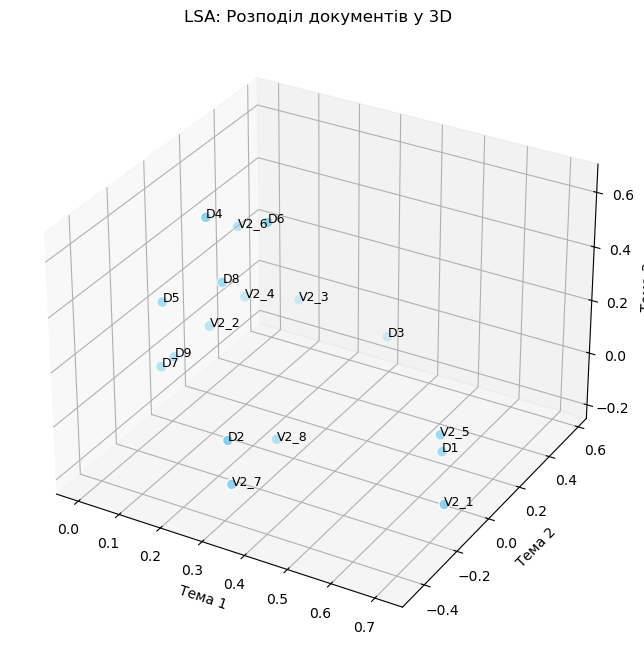

In [53]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(lsa_doc_df['latent_1'], 
           lsa_doc_df['latent_2'], 
           lsa_doc_df['latent_3'], 
           c='skyblue', s=60, edgecolors='w')

for i, txt in enumerate(lsa_doc_df.index):
    ax.text(lsa_doc_df['latent_1'].iloc[i], 
            lsa_doc_df['latent_2'].iloc[i], 
            lsa_doc_df['latent_3'].iloc[i], 
            txt, size=9)

ax.set_xlabel('Тема 1')
ax.set_ylabel('Тема 2')
ax.set_zlabel('Тема 3')
plt.title('LSA: Розподіл документів у 3D')
plt.show()

## 7. Найвагоміші терміни латентних компонент

Щоб інтерпретувати сенс кожної компоненти, розглянемо терміни з найбільшими вагами у відповідних векторах.
Перша тема це явно машинне навчання, моделювання.
Друга тема це обробка природньої мови.
Третя тема це решта: виявлення і аналіз контенту.


In [55]:
for i, comp in enumerate(lsa.components_):
    print(f"Латентна компонента {i+1}:")
    top_idx = comp.argsort()[-8:][::-1]
    for idx in top_idx:
        print(f"  {terms_tfidf[idx]:<20} {comp[idx]:.4f}")
    print()


Латентна компонента 1:
  модел                0.3320
  навчання             0.3219
  машинн               0.3119
  аналіз               0.2687
  класифікації         0.2358
  тематичн             0.2165
  науков               0.1845
  оцінювання           0.1728

Латентна компонента 2:
  обробк               0.2892
  використов           0.2461
  мов                  0.1932
  природної            0.1932
  підход               0.1932
  нейромережев         0.1932
  аналітик             0.1919
  статистичн           0.1916

Латентна компонента 3:
  виявлення            0.3144
  аналіз               0.2589
  контент              0.2417
  соціальн             0.2221
  повідомлень          0.1839
  моніторинг           0.1839
  передбачає           0.1839
  збирання             0.1839



## 8. Побудова LSA-biplot: документи і терміни

Показуємо додатково до положення документів у 3d ще і терміни із їх векторним відображенням. Тепер ми можемо побачити, що у наших документах, насправді, є чотири напрямки: машинне навчання, моделювання, аналіз даних, аналіз контенту.


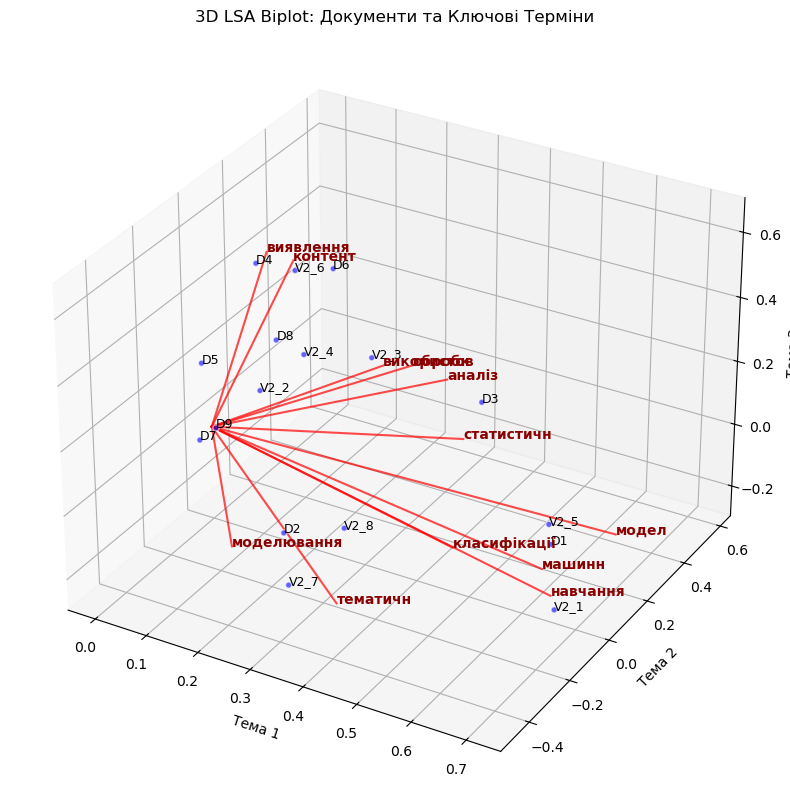

In [60]:
term_coords = lsa.components_.T[:, :3] 

term_strength = np.linalg.norm(term_coords, axis=1)

top_term_idx = np.argsort(term_strength)[-12:]
selected_terms = terms_tfidf[top_term_idx]
selected_term_coords = term_coords[top_term_idx]

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_lsa[:, 0], X_lsa[:, 1], X_lsa[:, 2], alpha=0.6, c='blue', edgecolors='w')

for i, label in enumerate(analysis_df["doc_id"]):
    ax.text(X_lsa[i, 0], X_lsa[i, 1], X_lsa[i, 2], label, fontsize=9)

scale = 2
for i, term in enumerate(selected_terms):
    x, y, z = selected_term_coords[i] * scale
    ax.plot([0, x], [0, y], [0, z], color='red', alpha=0.7, lw=1.5)
    ax.text(x, y, z, term, color='darkred', fontweight='bold', fontsize=10)

ax.set_xlabel("Тема 1")
ax.set_ylabel("Тема 2")
ax.set_zlabel("Тема 3")
ax.set_title("3D LSA Biplot: Документи та Ключові Терміни")

plt.show()

## 9. Побудова LDA-моделі

Для LDA використовують не TF-IDF, а *частотну матрицю* термінів, оскільки модель працює саме з генеративною структурою появи слів у документах.


In [67]:
count_vectorizer = CountVectorizer()
X_count = count_vectorizer.fit_transform(analysis_df["analysis_text"])

terms_count = count_vectorizer.get_feature_names_out()

count_df = pd.DataFrame(
    X_count.toarray(),
    index=analysis_df["doc_id"],
    columns=terms_count
)

display(count_df.iloc[:5, :15])

lda = LatentDirichletAllocation(
    n_components=3,
    random_state=42,
    learning_method="batch"
)

X_topics = lda.fit_transform(X_count)

doc_topic_df = pd.DataFrame(
    np.round(X_topics, 4),
    columns=["topic_1", "topic_2", "topic_3"],
    index=analysis_df["doc_id"]
)

display(doc_topic_df)


,idf,python,tf,автоматичн,алгоритм,аналіз,аналітик,бот,будуват,важлив,векторизацію,взаємодію,викладач,використов,виявлення
doc_id,,,,,,,,,,,,,,,
D1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
D2,1,0,1,0,0,1,0,0,0,0,1,0,0,0,0
D3,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
D4,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
D5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,topic_1,topic_2,topic_3
doc_id,,,
D1,0.9369,0.0317,0.0314
D2,0.0320,0.0306,0.9374
D3,0.0389,0.9230,0.0381
D4,0.0312,0.0312,0.9376
D5,0.0335,0.9327,0.0338
D6,0.9312,0.0336,0.0352
D7,0.0336,0.0337,0.9328
D8,0.0338,0.0336,0.9326
D9,0.0336,0.0337,0.9328


## 10. Топ-слова для кожної теми LDA

Щоб зробити теми змістовно зрозумілими, виведемо слова з найбільшими вагами в кожній темі. Виходить, що перша тема знов-таки про машинне навчання. Друга тема - обробка соціальних даних, третя тема - аналіз даних.


In [69]:
n_top_words = 8

for topic_idx, topic in enumerate(lda.components_):
    print(f"Тема {topic_idx + 1}:")
    top_term_indices = topic.argsort()[-n_top_words:][::-1]
    for idx in top_term_indices:
        print(f"  {terms_count[idx]:<20} {topic[idx]:.4f}")
    print()


Тема 1:
  модел                2.3516
  навчання             2.3503
  машинн               2.3471
  навчальн             2.3328
  контент              2.3328
  текстов              2.3328
  допомагає            2.3328
  аналіз               2.3231

Тема 2:
  обробк               2.3329
  використов           1.3378
  оцінювання           1.3367
  соціальн             1.3365
  дан                  1.3353
  цифров               1.3352
  статистичн           1.3350
  аналітик             1.3349

Тема 3:
  аналіз               4.3429
  тематичн             2.3386
  результат            2.3327
  виявлення            1.3332
  моделювання          1.3331
  включає              1.3327
  tf                   1.3327
  документ             1.3327



## 11. Стовпчикова інтерпретація тематичного складу документів

Як видно, то за LDA кожен документ є тематично чистим. 


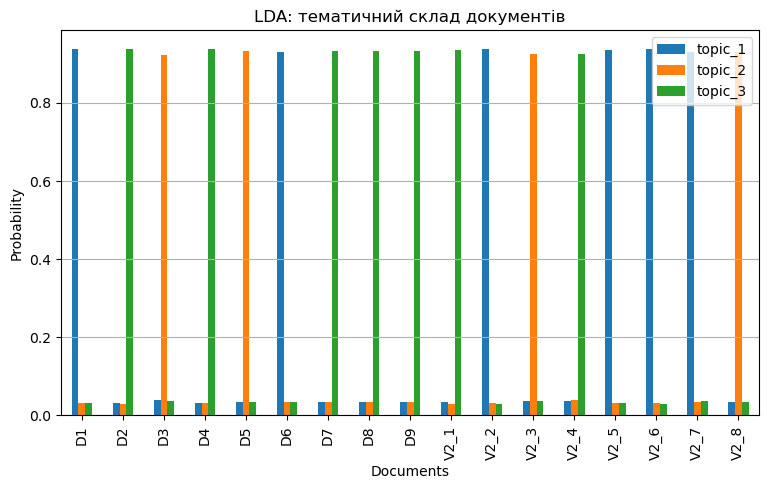

In [71]:
doc_topic_df.plot(kind="bar", figsize=(9, 5))

plt.ylabel("Probability")
plt.xlabel("Documents")
plt.title("LDA: тематичний склад документів")
plt.grid(axis="y")
plt.show()


## 12. Коротка інтерпретація результатів

У просторі LSA було наочно видно 4 групи найпопулярніших термінів. Якщо поділити групи, то можна побачити на 3d діаграми 5 невеликих кластерів: один по кожній групі термінів, а також змішана група. До знайдених тем належать: машинне навчання, моделювання, аналіз даних, аналіз контенту.
У просторі LDA групи виявились майже такими же: перша тема про машинне навчання і моделювання, друга - обробку соціальних даних, третя тема - аналіз даних. Документи, що були розпізнані як тематично змішані, не було виявлено. Проте, розподіл документів за LDA та LSA виявились різними.
LSA за свою основу використовує TF-IDF, що позначає важливість слів для того, аби відрізнями документи між собою, коли LDA використовує Bag of World і базується на ймовірностях. За допомогою геометричної інтерпретації можна легко візуалізувати документи у просторі ознак, коли за допомогою ймовірнісної легко побачити, до якої теми стосується документ.

## Висновки

У ході лабораторної роботи було:

- сформовано навчальний корпус документів;
- виконано підготовку текстів до аналізу;
- побудовано *TF-IDF*-матрицю і застосовано *LSA*;
- виконано візуалізацію документів у латентному просторі;
- побудовано *biplot* для документів і термінів;
- побудовано *LDA*-модель;
- отримано тематичний опис корпусу на основі ймовірнісного підходу.

У результаті було продемонстровано, що *LSA* і *LDA* не є взаємовиключними методами, а радше двома різними способами інтерпретації текстового корпусу.


## Контрольні питання

1. У чому принципова відмінність між *LSA* та *LDA*?
Принципова відмінність полягає в тому, що LSA є лінійним алгебраїчним методом розкладу матриці, а LDA — імовірнісною моделлю генерації тем і слів.
2. Чому для *LSA* зручно використовувати *TF-IDF*, а для *LDA* -- *CountVectorizer*?
Для LSA зручно використовувати TF-IDF, бо він підсилює значущі слова, а для LDA CountVectorizer, бо модель працює з реальними кількостями появ слів.
3. Що означає латентна компонента у *LSA*?
Латентна компонента у LSA означає прихований семантичний фактор, що об’єднує пов’язані слова та документи.
4. Як інтерпретувати тему в *LDA*?
Тему в LDA інтерпретують як розподіл імовірностей слів, де найвагоміші слова описують її зміст.
5. Для чого у *LSA* виконується зниження розмірності?
У LSA зниження розмірності виконується для виділення головних прихованих структур і зменшення шуму в даних.
6. Що показує *biplot*?
Biplot показує одночасне розміщення документів і термінів у просторі головних компонент або тем.
7. Як визначити, що документ має змішану тематику?
Документ має змішану тематику, якщо він отримує значущі ваги чи ймовірності одразу для кількох тем.
8. Чому тематичні моделі важливі в аналізі соціальних медіа?
Тематичні моделі важливі в аналізі соціальних медіа, бо дозволяють автоматично виявляти головні теми та тренди у великих потоках повідомлень.
